In [ ]:
# !pip install matplotlib numpy pandas wandb x-transformers nbconvert ipykernel datasets tqdm
# !pip install ipywidgets --upgrade

# !sudo apt install unzip -y

# !git clone https://github.com/fchollet/ARC.git
# !git clone https://github.com/michaelhodel/re-arc.git
# !cd re-arc && unzip re_arc.zip

# !rm -rf re-arc/.git
# !rm -rf ARC/.git

# !pip install gdown
# !gdown --folder https://drive.google.com/drive/folders/1LIc90R2MYaY_2ErAYywPZJP-SFspZt44 -O ./arc-prize-2025

In [ ]:
#!pip install scipy scikit-learn umap-learn

In [3]:
import sys
print(sys.version)

In [4]:
import os
from os.path import join as path_join
import json
from pathlib import Path
from functools import reduce
import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1 import ImageGrid
import matplotlib.patches as patches
import io
import time

import numpy as np
import pandas as pd
from PIL import Image
import datetime
import math
from tqdm import tqdm

In [5]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import LambdaLR

torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
from utils import *

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def prep_target_seq(input):
    # Create a new tensor with the same shape
    shifted_input = torch.empty_like(input)

    # Set the first token of every sequence to the start token
    shifted_input[:, 0] = SOS_TOKEN

    # Copy all tokens except the last one from input_examples to shifted_input_examples starting at position 1
    shifted_input[:, 1:] = input[:, :-1]

    return shifted_input

#### Datasets

In [7]:
data_path = Path('ARC/data')
training_path = data_path / 'training'
evaluation_path = data_path / 'evaluation'

In [8]:
# size is max 30x30
# integer between 0 and 9, which are visualized as colors

def store_tasks(path, is_train = True):
  training_tasks = sorted(os.listdir(path))
  records = [] 
  for task_name in training_tasks:
    task_file = str(path / task_name)

    with open(task_file, 'r') as f:
      task = json.load(f)

      for key in task:
        if key not in ['train', 'test']:
          continue
        for t in task[key]:
          rec = {
            'task_id' : task_name, 
            'input' : t['input'], 
            'output' : t['output'],
            'final_task': key != 'train',
            'train' : is_train 
          }
          records.append(rec)

  #df = pd.DataFrame(columns=['task_id', 'input', 'output', 'final_task', 'train']) 
  df = pd.DataFrame(records)
  
  return df


df_train = store_tasks(training_path, True) 
df_test = store_tasks(evaluation_path, False)
df = pd.concat([df_train, df_test])

train_task_ids = df_train['task_id'].unique()
test_task_ids = df_test['task_id'].unique()

In [9]:
def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)
    
training_challenges_path = 'arc-prize-2025/arc-agi_training_challenges.json'
training_solutions_path = 'arc-prize-2025/arc-agi_training_solutions.json'

evaluation_challenges_path = 'arc-prize-2025/arc-agi_evaluation_challenges.json'
evaluation_solutions_path = 'arc-prize-2025/arc-agi_evaluation_solutions.json'

training_challenges = load_json(training_challenges_path)
training_solutions = load_json(training_solutions_path)

evaluation_challenges = load_json(evaluation_challenges_path)
evaluation_solutions = load_json(evaluation_solutions_path)

print(len(training_challenges), len(training_solutions), len(evaluation_challenges), len(evaluation_solutions))

def create_arc2_dataset(challenges, solutions):
    records = []
    for key, value in challenges.items():
        # save examples
        for example in value['train']:
            rec = {
                'task_id' : key, 
                'input' : example['input'], 
                'output' : example['output'],
                'final_task': False,
            }
            records.append(rec)

        # save final task
        for task_input, task_output in zip(value['test'], solutions[key]):
            rec = {
                'task_id' : key, 
                'input' : task_input['input'], 
                'output' : task_output,
                'final_task': True,
            }
            records.append(rec)

    return records

df_train_arc2 = pd.DataFrame(create_arc2_dataset(training_challenges, training_solutions))
df_test_arc2 = pd.DataFrame(create_arc2_dataset(evaluation_challenges, evaluation_solutions))

train_task_ids_arc2 = df_train_arc2['task_id'].unique()
test_task_ids_arc2 = df_test_arc2['task_id'].unique()

1000 1000 120 120


In [10]:
NUMBER_OF_COLORS = 10 +1 +1 # integer between 0 and 9 = 10, and +1 my class (used as background (10)) + 1 for SOS token
MAX_IMAGE_SIZE = 32
MAX_SEQUENCE_SIZE = MAX_IMAGE_SIZE * MAX_IMAGE_SIZE
BACKGROUND_CLASS = 10
SOS_TOKEN = 11

# make all images 32 by 32 and fill empty spaces by additional class
def placeholder(arg, sizes = (MAX_IMAGE_SIZE, MAX_IMAGE_SIZE), background=BACKGROUND_CLASS):
  img = np.array(arg)
  holder = np.full(sizes, background, dtype=int)
  holder[0:img.shape[0], 0:img.shape[1]] = img

  return holder

In [11]:
class CustomDatasetTestTransformationsDiscrete(Dataset):
    def __init__(self, task_ids, df, n_of_samples=2):
        self.task_ids = task_ids
        self.data_by_task_id = {
            task_id: df.query(f'task_id == "{task_id}"').to_dict(orient='records')
            for task_id in task_ids
        }
        self.n_of_samples = n_of_samples
        
    def __len__(self):
        return len(self.task_ids)

    def __getitem__(self, idx):
        task_id = self.task_ids[idx]
        examples = self.data_by_task_id[task_id]
        selected_examples = random.sample(examples, self.n_of_samples + 1)

        transformation_1 = sample_transformations()
        transformation_2 = lambda x: placeholder(transformation_1(x))
        transformation_32 = lambda x: torch.tensor(transformation_2(x).flatten(), dtype=torch.long)

        data_item_input = [transformation_32(example['input']) for example in selected_examples]
        data_item_output = [transformation_32(example['output']) for example in selected_examples]

        return [
            torch.stack(data_item_input[:self.n_of_samples]), torch.stack(data_item_output[:self.n_of_samples]), 
            torch.stack(data_item_input[self.n_of_samples:]), torch.stack(data_item_output[self.n_of_samples:]),
        ]
    

class CustomDatasetTestTransformationsAdaptDiscrete(Dataset):
    def __init__(self, task_ids, df, n_of_samples=2):
        self.task_ids = task_ids
        self.data_by_task_id = {
            task_id: df.query(f'task_id == "{task_id}"').to_dict(orient='records')
            for task_id in task_ids
        }
        self.n_of_samples = n_of_samples
        self.df = df
        
    def __len__(self):
        return len(self.task_ids)

    def __getitem__(self, idx):
        task_id = self.task_ids[idx]
        examples = self.df.query(f'final_task == False and task_id == "{task_id}"').to_dict(orient='records')
        selected_examples = random.sample(examples, self.n_of_samples)

        final_task = self.df.query(f'final_task == True and task_id == "{task_id}"').to_dict(orient='records')[0]

        transformation_1 = sample_transformations()
        transformation_2 = lambda x: placeholder(transformation_1(x))
        transformation_32 = lambda x: torch.tensor(transformation_2(x).flatten(), dtype=torch.long)

        data_item_input = [transformation_32(example['input']) for example in selected_examples]
        data_item_output = [transformation_32(example['output']) for example in selected_examples]
        data_item_input_d = [transformation_32(final_task['input'])]
        data_item_output_d = [transformation_32(final_task['output'])]

        return [
            torch.stack(data_item_input), torch.stack(data_item_output), 
            torch.stack(data_item_input_d), torch.stack(data_item_output_d)
        ]
    

class CustomDatasetTestTransformationsDiscreteReArc2(Dataset):
    def __init__(self, task_ids, data_points, n_of_samples=2):
        self.task_ids = task_ids
        self.data_points = data_points
        self.n_of_samples = n_of_samples
        self.task_data = self._load_all_tasks()
        
    def _load_all_tasks(self):
        """Preloads all task files into memory."""
        task_data = {}
        for task_id in self.task_ids:
            task_file = f're-arc/re_arc/tasks/{task_id}'
            with open(task_file, 'r') as f:
                examples = json.load(f)

                examples_filtered = []
                for example in examples:
                    if len(example['input']) <= 32 and len(example['input'][0]) <= 32 and len(example['output']) <= 32 and len(example['output'][0]) <= 32:
                        examples_filtered.append(example)

                task_data[task_id] = examples_filtered
        return task_data
    
    def __len__(self):
        return len(self.task_ids)

    def __getitem__(self, idx):
        task_id = self.task_ids[idx]
        examples = self.task_data[task_id]  # Fetch preloaded data
        
        selected_examples = random.sample(examples, self.n_of_samples+1)

        transformation_1 = sample_transformations()
        transformation_2 = lambda x: placeholder(transformation_1(x))
        transformation_32 = lambda x: torch.tensor(transformation_2(x).flatten(), dtype=torch.long)

        data_item_input = [transformation_32(example['input']) for example in selected_examples]
        data_item_output = [transformation_32(example['output']) for example in selected_examples]

        return [
            torch.stack(data_item_input[:self.n_of_samples]), torch.stack(data_item_output[:self.n_of_samples]), 
            torch.stack(data_item_input[self.n_of_samples:]), torch.stack(data_item_output[self.n_of_samples:]),
        ]

In [12]:
# # make sure arc task is not in the re-arc dataset
# def get_arc_rearc_tasks(task_id):
#     task_file = f're-arc/re_arc/tasks/{task_id}'
#     with open(task_file, 'r') as f:
#         examples = json.load(f)

#         examples_filtered = []
#         for example in examples:
#             if len(example['input']) <= 32 and len(example['input'][0]) <= 32 and len(example['output']) <= 32 and len(example['output'][0]) <= 32:
#                 examples_filtered.append(example)
#     rearc_tasks = examples_filtered


#     data = df.query(f'task_id == "{task_id}"').to_dict(orient='records')
#     arc_tasks = []
#     for example in data:
#         arc_tasks.append({
#             'input': example['input'],
#             'output': example['output'],
#         })

#     return rearc_tasks, arc_tasks

# #task_id = '0a938d79.json'
# for task_id in train_task_ids:
#     rearc_tasks, arc_tasks = get_arc_rearc_tasks(task_id)
#     #print(task_id, len(rearc_tasks), len(arc_tasks))
#     for rearc_task in rearc_tasks:
#         for arc_task in arc_tasks:
#             if rearc_task['input'] == arc_task['input']:
#                 print(rearc_task['input'], rearc_task['output'])
#                 print(arc_task['input'], arc_task['output'])
#                 print('---')

In [13]:
class CustomDatasetTestTransformationsAdaptDiscreteAll(Dataset):
    def __init__(self, task_ids, df, max_examples=2):
        self.task_ids = task_ids
        self.data_by_task_id = {
            task_id: df.query(f'task_id == "{task_id}"').to_dict(orient='records')
            for task_id in task_ids
        }
        self.max_examples = max_examples
        
    def __len__(self):
        return len(self.task_ids)

    def __getitem__(self, idx):
        task_id = self.task_ids[idx]
        task_data = self.data_by_task_id[task_id]
        
        # Select all non-final examples for the task
        examples = [d for d in task_data if not d['final_task']]
        random.shuffle(examples)  # Shuffle examples
        examples = examples[:self.max_examples]  # Limit to max_examples


        # Get the final task example
        final_task = [d for d in task_data if d['final_task']][0]

        # Apply transformations
        transformation_1 = sample_transformations()
        transformation_2 = lambda x: placeholder(transformation_1(x))
        transformation_32 = lambda x: torch.tensor(transformation_2(x).flatten(), dtype=torch.long)

        # Process all examples
        data_item_input = [transformation_32(ex['input']) for ex in examples]
        data_item_output = [transformation_32(ex['output']) for ex in examples]
        # Process final task
        data_item_input_d = [transformation_32(final_task['input'])]
        data_item_output_d = [transformation_32(final_task['output'])]

        return [
            torch.stack(data_item_input), torch.stack(data_item_output), 
            torch.stack(data_item_input_d), torch.stack(data_item_output_d)
        ]
    

class CustomDatasetTestTransformationsDiscreteWithoutTaskAll(Dataset):
    def __init__(self, task_ids, df, max_examples=2):
        self.task_ids = task_ids
        self.data_by_task_id = {
            task_id: df.query(f'task_id == "{task_id}"').to_dict(orient='records')
            for task_id in task_ids
        }
        self.max_examples = max_examples
        
    def __len__(self):
        return len(self.task_ids)

    def __getitem__(self, idx):
        task_id = self.task_ids[idx]
        task_data = self.data_by_task_id[task_id]
        
        examples = [d for d in task_data if not d['final_task']]
        random.shuffle(examples) 
        final_task = examples.pop()
        examples = examples[:self.max_examples] 

        # Apply transformations
        transformation_1 = sample_transformations()
        transformation_2 = lambda x: placeholder(transformation_1(x))
        transformation_32 = lambda x: torch.tensor(transformation_2(x).flatten(), dtype=torch.long)

        # Process all examples
        data_item_input = [transformation_32(ex['input']) for ex in examples]
        data_item_output = [transformation_32(ex['output']) for ex in examples]
        # Process final task
        data_item_input_d = [transformation_32(final_task['input'])]
        data_item_output_d = [transformation_32(final_task['output'])]

        return [
            torch.stack(data_item_input), torch.stack(data_item_output), 
            torch.stack(data_item_input_d), torch.stack(data_item_output_d)
        ]

#### Models

In [14]:
from x_transformers import TransformerWrapper, Encoder, Decoder, PrefixDecoder
from x_transformers.autoregressive_wrapper import AutoregressiveWrapper

In [15]:
class TwoDimPositionalEmbedding(nn.Module):
    def __init__(self, height=32, width=32, dim=32):
        super().__init__()
        self.height = height
        self.width = width
        self.dim = dim

        # Separate embeddings for height and width
        self.row_embed = nn.Embedding(height, dim)
        self.col_embed = nn.Embedding(width, dim)

        # Initialize weights (if needed)
        #nn.init.normal_(self.row_embed.weight, std=0.02)
        #nn.init.normal_(self.col_embed.weight, std=0.02)

    def forward(self, batch_size):
        # Generate grid of row and column indices
        row_positions = torch.arange(self.height, device=self.row_embed.weight.device).unsqueeze(1).expand(self.height, self.width).flatten()
        col_positions = torch.arange(self.width, device=self.row_embed.weight.device).unsqueeze(0).expand(self.height, self.width).flatten()

        # Get embeddings
        row_pos_emb = self.row_embed(row_positions)  # Shape: (height * width, dim)
        col_pos_emb = self.col_embed(col_positions)  # Shape: (height * width, dim)

        # Combine the two positional embeddings
        pos_emb = row_pos_emb + col_pos_emb  # Shape: (height * width, dim)

        # Expand to batch size
        pos_emb = pos_emb.unsqueeze(0).expand(batch_size, -1, -1)  # Shape: (batch_size, height * width, dim)

        return pos_emb

In [16]:
class EncoderDecoder2dPosModel(nn.Module):
    def __init__(self, num_tokens=NUMBER_OF_COLORS, max_seq_len=MAX_SEQUENCE_SIZE, dim=64, depth=4, heads=8, 
                 pos_emb_2d_encoder=True, pos_emb_2d_decoder=True):
        super().__init__()

        self.dim = dim
        self.depth = depth
        self.heads = heads
        self.pos_emb_2d_encoder = pos_emb_2d_encoder
        self.pos_emb_2d_decoder = pos_emb_2d_decoder

        if pos_emb_2d_encoder or pos_emb_2d_decoder:
            self.pos_enc = TwoDimPositionalEmbedding(height=MAX_IMAGE_SIZE, width=MAX_IMAGE_SIZE, dim=dim)

        self.encoder_model = TransformerWrapper(
            num_tokens = num_tokens,
            max_seq_len = max_seq_len,
            attn_layers = Encoder(
                dim = dim,
                depth = depth,
                heads = heads,
                attn_flash = True
            )
        )
        
        self.decoder = TransformerWrapper(
            num_tokens = num_tokens,
            max_seq_len = max_seq_len,
            attn_layers = Decoder(
                dim = dim,
                depth = depth,
                heads = heads,
                cross_attend = True,
                attn_flash = True
            )
        )

        # If your model is wrapped in DistributedDataParallel (DDP),
        # access the underlying model using model.module
        model_to_freeze = self.module if hasattr(self, "module") else self

        # List of parameter names from the underlying model (without the "module." prefix)
        freeze_params = {
            "encoder_model.pos_emb.emb.weight",
            "encoder_model.to_logits.weight",
            "decoder.pos_emb.emb.weight"
        }

        # Iterate over the underlying model's parameters
        for name, param in model_to_freeze.named_parameters():
            if name in freeze_params:
                param.requires_grad = False
                print(f"Freezing parameter: {name}")

    def forward(self, get_predictions, input_examples, output_examples, input_task, output_task, device):
        loss, _, _, _, _ = get_predictions(self, input_examples, output_examples, input_task, output_task, device=device)
        return loss

    def encode(self, x):
        """
        Encode the input sequence into embeddings.
        
        Parameters:
            x (Tensor): Input tokens of shape [batch_size, sequence_length].
            mask (Tensor, optional): A mask to be applied to the attention mechanism.
        
        Returns:
            Tensor: Embeddings of shape [batch_size, sequence_length, embedding_dim].
        """
        # The TransformerWrapper returns the output embeddings if `return_embeddings=True`
        mask = torch.ones_like(x).bool()

        if self.pos_emb_2d_encoder:
            pos_emb = self.pos_enc(x.shape[0])
            embeddings = self.encoder_model(x, mask=mask, return_embeddings=True, pos = pos_emb)
        else:
            embeddings = self.encoder_model(x, mask=mask, return_embeddings=True)

        return embeddings

    def decode(self, x, context_embeddings, do_prep_target_seq=True):
        """
        Decode embeddings back into a distribution over tokens.
        
        Parameters:
            embeddings (Tensor): Embeddings from the encoder of shape [batch_size, sequence_length, embedding_dim].
            
        Returns:
            Tensor: Logits over tokens of shape [batch_size, sequence_length, num_tokens].
        """
        if self.pos_emb_2d_decoder:
            pos_emb = self.pos_enc(x.shape[0])
            pos_emb = pos_emb[:, :x.shape[1], :] # generate seauence of the same length as x, 1,2,3,...
            logits = self.decoder(prep_target_seq(x) if do_prep_target_seq else x, context=context_embeddings, pos=pos_emb)
        else:
            logits = self.decoder(prep_target_seq(x) if do_prep_target_seq else x, context=context_embeddings)
        return logits
    
    @torch.no_grad()
    def generate(self, context_embeddings, temperature=0):
        """
        Autoregressively generate a sequence given context embeddings.
        
        Parameters:
            context_embeddings (Tensor): Encoder outputs of shape [batch_size, seq_len, dim].
            temperature (float): Sampling temperature. 0 → greedy (argmax).
            max_len (int): Maximum number of tokens to generate.
            start_token (int): Token ID to start decoding with.
        
        Returns:
            Tensor: Generated sequence of shape [batch_size, max_len].
        """
        device = context_embeddings.device
        bs = context_embeddings.size(0)
        
        # Start with a tensor containing only the start token
        generated = torch.full((bs, 1), SOS_TOKEN, dtype=torch.long, device=device)
        
        for _ in range(MAX_SEQUENCE_SIZE - 1):
            logits = self.decode(
                generated,
                context_embeddings=context_embeddings,
                do_prep_target_seq=False
            )
            
            # Take the last predicted token logits
            next_token_logits = logits[:, -1, :]
            
            if temperature == 0:
                # Greedy decoding
                next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
            else:
                # Sampling decoding
                probs = torch.softmax(next_token_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
            
            # Append predicted token
            generated = torch.cat([generated, next_token], dim=1)
        
        return generated

#### Get Predictions and Losses

In [17]:
def get_predictions_simple(model, input_examples, output_examples, input_task, output_task):
    n_examples = input_examples.shape[1]
    
    input_examples = input_examples.to(device)
    output_examples = output_examples.to(device)
    input_task = input_task.to(device)
    output_task = output_task.to(device)

    input_examples = input_examples.view(-1, MAX_SEQUENCE_SIZE)
    input_examples_emb = model.encode(input_examples)
    input_examples_emb = input_examples_emb.view(-1, n_examples, MAX_SEQUENCE_SIZE, input_examples_emb.shape[-1])

    output_examples = output_examples.view(-1, MAX_SEQUENCE_SIZE)
    output_examples_emb = model.encode(output_examples)
    output_examples_emb = output_examples_emb.view(-1, n_examples, MAX_SEQUENCE_SIZE, output_examples_emb.shape[-1])

    input_task = input_task.view(-1, MAX_SEQUENCE_SIZE)
    input_task_emb = model.encode(input_task)
    input_task_emb = input_task_emb.view(-1, 1, MAX_SEQUENCE_SIZE, input_task_emb.shape[-1])

    output_task = output_task.view(-1, MAX_SEQUENCE_SIZE)
    output_task_emb = model.encode(output_task)
    output_task_emb = output_task_emb.view(-1, 1, MAX_SEQUENCE_SIZE, output_task_emb.shape[-1])

    # ----------------------------
    c = (output_examples_emb - input_examples_emb).mean(dim=(1, 2), keepdim=True)
    
    # calculate embedding losses
    input_examples_emb_est = output_examples_emb - c
    output_examples_emb_est = input_examples_emb + c

    input_task_emb_est = output_task_emb - c
    output_task_emb_est = input_task_emb + c

    em_dim = model.dim
    loss_reconstracted_emb_1 = F.mse_loss(input_examples_emb_est.view(-1, em_dim), input_examples_emb.view(-1, em_dim))
    loss_reconstracted_emb_2 = F.mse_loss(output_examples_emb_est.view(-1, em_dim), output_examples_emb.view(-1, em_dim))
    loss_reconstracted_emb_3 = F.mse_loss(input_task_emb_est.view(-1, em_dim), input_task_emb.view(-1, em_dim))
    loss_reconstracted_emb_4 = F.mse_loss(output_task_emb_est.view(-1, em_dim), output_task_emb.view(-1, em_dim))
    loss_reconstracted_emb = loss_reconstracted_emb_1 + loss_reconstracted_emb_2 + loss_reconstracted_emb_3 + loss_reconstracted_emb_4

    # calculate reconstruction losses
    em_dim = model.dim
    input_examples_est_reconstracted = model.decode(input_examples, input_examples_emb_est.view(-1, MAX_SEQUENCE_SIZE, em_dim))
    output_examples_est_reconstracted = model.decode(output_examples, output_examples_emb_est.view(-1, MAX_SEQUENCE_SIZE, em_dim))
    input_task_est_reconstracted = model.decode(input_task, input_task_emb_est.view(-1, MAX_SEQUENCE_SIZE, em_dim))
    output_task_est_reconstracted = model.decode(output_task, output_task_emb_est.view(-1, MAX_SEQUENCE_SIZE, em_dim))

    loss_reconstracted_img_1 = F.cross_entropy(input_examples_est_reconstracted.view(-1, NUMBER_OF_COLORS), input_examples.view(-1))
    loss_reconstracted_img_2 = F.cross_entropy(output_examples_est_reconstracted.view(-1, NUMBER_OF_COLORS), output_examples.view(-1))
    loss_reconstracted_img_3 = F.cross_entropy(input_task_est_reconstracted.view(-1, NUMBER_OF_COLORS), input_task.view(-1))
    loss_reconstracted_img_4 = F.cross_entropy(output_task_est_reconstracted.view(-1, NUMBER_OF_COLORS), output_task.view(-1))
    loss_reconstracted_img = loss_reconstracted_img_1 + loss_reconstracted_img_2 + loss_reconstracted_img_3 + loss_reconstracted_img_4

    loss = 0.01 * loss_reconstracted_emb + loss_reconstracted_img
    #loss += 0.1 * torch.mean(torch.abs(c))
    loss += 0.1 * torch.mean(c.pow(2))

    loss_log = {
        'total_loss': loss.item(),
        'loss_reconstracted_img_1': loss_reconstracted_img_1.item(),
        'loss_reconstracted_img_2': loss_reconstracted_img_2.item(),
        'loss_reconstracted_img_3': loss_reconstracted_img_3.item(),
        'loss_reconstracted_img_4': loss_reconstracted_img_4.item(),
        'loss_reconstracted_img': loss_reconstracted_img.item(),
        
        'loss_reconstracted_emb': loss_reconstracted_emb.item(),
        'loss_reconstracted_emb_1': loss_reconstracted_emb_1.item(),
        'loss_reconstracted_emb_2': loss_reconstracted_emb_2.item(),
        'loss_reconstracted_emb_3': loss_reconstracted_emb_3.item(),
        'loss_reconstracted_emb_4': loss_reconstracted_emb_4.item(),
    }

    emb_data = (input_examples_emb_est, output_examples_emb_est, input_task_emb_est, output_task_emb_est)
    decoded_data = (input_examples_est_reconstracted, output_examples_est_reconstracted, input_task_est_reconstracted, output_task_est_reconstracted)

    return loss, emb_data, decoded_data, loss_log

In [18]:
def run_eval(model, dataloader, device=device, n_generate_tests=0):
    total_loss = 0.0
    total_loss_reconstracted_emb = 0.0
    total_loss_reconstracted_img = 0.0

    total_loss_reconstracted_img_1 = 0.0
    total_loss_reconstracted_img_2 = 0.0
    total_loss_reconstracted_img_3 = 0.0
    total_loss_reconstracted_img_4 = 0.0

    all_correct_img_1 = 0
    all_correct_img_2 = 0
    all_correct_img_3 = 0
    all_correct_img_4 = 0

    proportion_correct_img_1 = 0
    proportion_correct_img_2 = 0
    proportion_correct_img_3 = 0
    proportion_correct_img_4 = 0

    K=1

    with torch.no_grad():
        model.eval()

        for batch_idx, (input_examples, output_examples, input_task, output_task) in enumerate(dataloader):
            loss, _, (input_examples_est_reconstracted, output_examples_est_reconstracted, input_task_est_reconstracted, output_task_est_reconstracted), loss_log = get_predictions_simple(model, input_examples, output_examples, input_task, output_task)

        # for batch_idx, (input_examples, output_examples, input_task, output_task, mask) in enumerate(dataloader):
        #     loss, _, (input_examples_est_reconstracted, output_examples_est_reconstracted, input_task_est_reconstracted, output_task_est_reconstracted), loss_log = get_predictions_simple_mask(model, input_examples, output_examples, input_task, output_task, mask, device)

            total_loss += loss.item()
            total_loss_reconstracted_emb += loss_log['loss_reconstracted_emb']
            total_loss_reconstracted_img += loss_log['loss_reconstracted_img']
            total_loss_reconstracted_img_1 += loss_log['loss_reconstracted_img_1']
            total_loss_reconstracted_img_2 += loss_log['loss_reconstracted_img_2']
            total_loss_reconstracted_img_3 += loss_log['loss_reconstracted_img_3']
            total_loss_reconstracted_img_4 += loss_log['loss_reconstracted_img_4']

            # ---- TOP-K ACCURACY CALCULATION ----
            input_examples = input_examples.view(-1, MAX_SEQUENCE_SIZE).to(device)
            output_examples = output_examples.view(-1, MAX_SEQUENCE_SIZE).to(device)
            input_task = input_task.view(-1, MAX_SEQUENCE_SIZE).to(device)
            output_task = output_task.view(-1, MAX_SEQUENCE_SIZE).to(device)

            # For each set of predicted logits, find top-k predictions
            # input2_est_reconstracted: [batch_size, MAX_SEQUENCE_SIZE, NUMBER_OF_COLORS]
            topk_input2 = torch.topk(input_examples_est_reconstracted, k=K, dim=-1).indices  # shape: [batch_size, MAX_SEQUENCE_SIZE, K]
            topk_output2 = torch.topk(output_examples_est_reconstracted, k=K, dim=-1).indices
            topk_input_21 = torch.topk(input_task_est_reconstracted, k=K, dim=-1).indices
            topk_output_21 = torch.topk(output_task_est_reconstracted, k=K, dim=-1).indices

            # Check for correctness: a pixel is correct if the ground truth is in the top-k predictions
            correct_pixels_img_1 = (topk_input2 == input_examples.unsqueeze(-1)).any(dim=-1)
            correct_pixels_img_2 = (topk_output2 == output_examples.unsqueeze(-1)).any(dim=-1)
            correct_pixels_img_3 = (topk_input_21 == input_task.unsqueeze(-1)).any(dim=-1)
            correct_pixels_img_4 = (topk_output_21 == output_task.unsqueeze(-1)).any(dim=-1)

            # all_correct_img_x: count how many images have all pixels correct
            all_correct_img_1 += torch.sum(torch.all(correct_pixels_img_1, dim=1)).item()
            all_correct_img_2 += torch.sum(torch.all(correct_pixels_img_2, dim=1)).item()
            all_correct_img_3 += torch.sum(torch.all(correct_pixels_img_3, dim=1)).item()
            all_correct_img_4 += torch.sum(torch.all(correct_pixels_img_4, dim=1)).item()

            # proportion_correct_img_x: average proportion of correctly predicted pixels
            proportion_correct_img_1 += correct_pixels_img_1.float().mean().item()
            proportion_correct_img_2 += correct_pixels_img_2.float().mean().item()
            proportion_correct_img_3 += correct_pixels_img_3.float().mean().item()
            proportion_correct_img_4 += correct_pixels_img_4.float().mean().item()

            # perplexity
            ppl_img1 = math.exp(loss_log['loss_reconstracted_img_1'])
            ppl_img2 = math.exp(loss_log['loss_reconstracted_img_2'])
            ppl_img3 = math.exp(loss_log['loss_reconstracted_img_3'])
            ppl_img4 = math.exp(loss_log['loss_reconstracted_img_4'])


    total_images = len(dataloader)

    avg_proportion_correct_img_1 = proportion_correct_img_1 / total_images
    avg_proportion_correct_img_2 = proportion_correct_img_2 / total_images
    avg_proportion_correct_img_3 = proportion_correct_img_3 / total_images
    avg_proportion_correct_img_4 = proportion_correct_img_4 / total_images

    total_loss, total_loss_reconstracted_emb, total_loss_reconstracted_img = total_loss / total_images, total_loss_reconstracted_emb / total_images, total_loss_reconstracted_img / total_images
    total_loss_reconstracted_img_1, total_loss_reconstracted_img_2, total_loss_reconstracted_img_3, total_loss_reconstracted_img_4 = total_loss_reconstracted_img_1 / total_images, total_loss_reconstracted_img_2 / total_images, total_loss_reconstracted_img_3 / total_images, total_loss_reconstracted_img_4 / total_images

    # print('All correct gueses', len(train_loader_transformations.dataset), all_correct_img_1, all_correct_img_2, all_correct_img_3, all_correct_img_4)
    # print('Proportion of correct pixels for each image:', avg_proportion_correct_img_1, avg_proportion_correct_img_2, avg_proportion_correct_img_3, avg_proportion_correct_img_4)
    # print('Total loss', total_loss, total_loss_reconstracted_emb, total_loss_reconstracted_img)

    data = {
        "total_loss": total_loss,
        "total_loss_reconstracted_emb": total_loss_reconstracted_emb,
        "total_loss_reconstracted_img": total_loss_reconstracted_img,
        "total_loss_reconstracted_img_1": total_loss_reconstracted_img_1,
        "total_loss_reconstracted_img_2": total_loss_reconstracted_img_2,
        "total_loss_reconstracted_img_3": total_loss_reconstracted_img_3,
        "total_loss_reconstracted_img_4": total_loss_reconstracted_img_4,
        "avg_proportion_correct_img_1": avg_proportion_correct_img_1,
        "avg_proportion_correct_img_2": avg_proportion_correct_img_2,
        "avg_proportion_correct_img_3": avg_proportion_correct_img_3,
        "avg_proportion_correct_img_4": avg_proportion_correct_img_4,
        "all_correct_img_1": all_correct_img_1,
        "all_correct_img_2": all_correct_img_2,
        "all_correct_img_3": all_correct_img_3,
        "all_correct_img_4": all_correct_img_4,
        "perplexity_img_1": ppl_img1,
        "perplexity_img_2": ppl_img2,
        "perplexity_img_3": ppl_img3,
        "perplexity_img_4": ppl_img4       
    }

    return data

### Explore embeddings

In [19]:
batch_size_train = 8 #64*4

# train data loader

# dataset_train_transformations = CustomDatasetTestTransformationsDiscreteReArc2(train_task_ids, df_train)
# #train_loader_transformations = DataLoader(dataset_train_transformations, batch_size=batch_size_train, shuffle=True, drop_last=True)

dataset_train_transformations = CustomDatasetTestTransformationsAdaptDiscrete(train_task_ids, df_train)
#train_loader_transformations = DataLoader(dataset_train_transformations, batch_size=batch_size_train, shuffle=True, drop_last=True)


dataset_train_transformations = CustomDatasetTestTransformationsAdaptDiscrete(train_task_ids, df_train)
train_loader_transformations = DataLoader(dataset_train_transformations, batch_size=batch_size_train,
        shuffle=True,  # This is still useful for training
        num_workers=min(8, os.cpu_count()),
        persistent_workers=True,  # Keep workers alive between epochs
        prefetch_factor=32,
        pin_memory=True,
        drop_last=True)  # Prefetch batches)

# eval data loader
train_eval_loader_transformations = DataLoader(CustomDatasetTestTransformationsAdaptDiscrete(train_task_ids, df_train), batch_size=batch_size_train*3)
test_eval_loader_transformations = DataLoader(CustomDatasetTestTransformationsAdaptDiscrete(test_task_ids, df_test), batch_size=batch_size_train*3)
train_arc2_eval_loader_transformations = DataLoader(CustomDatasetTestTransformationsAdaptDiscrete(train_task_ids_arc2, df_train_arc2), batch_size=batch_size_train*3)
test_arc2_eval_loader_transformations = DataLoader(CustomDatasetTestTransformationsAdaptDiscrete(test_task_ids_arc2, df_test_arc2), batch_size=batch_size_train*3)

# # image generation data loader
# train_loader_image_gen = DataLoader(CustomDatasetTestTransformationsAdaptDiscrete(train_task_ids, df_train), batch_size=8, shuffle=True)
# test_loader_image_gen = DataLoader(CustomDatasetTestTransformationsAdaptDiscrete(test_task_ids, df_test), batch_size=8, shuffle=True)

In [20]:
@torch.no_grad()
def get_embeddings(model, input_examples, output_examples, input_task, output_task):
    n_examples = input_examples.shape[1]
    
    input_examples = input_examples.to(device)
    output_examples = output_examples.to(device)
    input_task = input_task.to(device)
    output_task = output_task.to(device)

    input_examples = input_examples.view(-1, MAX_SEQUENCE_SIZE)
    input_examples_emb = model.encode(input_examples)
    input_examples_emb = input_examples_emb.view(-1, n_examples, MAX_SEQUENCE_SIZE, input_examples_emb.shape[-1])

    output_examples = output_examples.view(-1, MAX_SEQUENCE_SIZE)
    output_examples_emb = model.encode(output_examples)
    output_examples_emb = output_examples_emb.view(-1, n_examples, MAX_SEQUENCE_SIZE, output_examples_emb.shape[-1])

    input_task = input_task.view(-1, MAX_SEQUENCE_SIZE)
    input_task_emb = model.encode(input_task)
    input_task_emb = input_task_emb.view(-1, 1, MAX_SEQUENCE_SIZE, input_task_emb.shape[-1])

    output_task = output_task.view(-1, MAX_SEQUENCE_SIZE)
    output_task_emb = model.encode(output_task)
    output_task_emb = output_task_emb.view(-1, 1, MAX_SEQUENCE_SIZE, output_task_emb.shape[-1])

    # ----------------------------
    c = (output_examples_emb - input_examples_emb).mean(dim=(1, 2), keepdim=True)
    
    # calculate embedding losses
    # input_examples_emb_est = output_examples_emb - c
    # output_examples_emb_est = input_examples_emb + c

    # input_task_emb_est = output_task_emb - c
    # output_task_emb_est = input_task_emb + c

    # Aggregate mean embeddings per task
    img_in = input_examples_emb.mean(dim=2)
    img_out = output_examples_emb.mean(dim=2)

    return c.view(-1, model.dim).detach().cpu().tolist(), img_in.detach().cpu(), img_out.detach().cpu()

@torch.no_grad()
def get_all_embeddings(model, loader):
    c_all, img_in_all, img_out_all = [], [], []

    for batch_idx, (input_examples, output_examples, input_task, output_task) in tqdm(enumerate(loader), total=len(loader)):
        c, img_in, img_out = get_embeddings(model, input_examples, output_examples, input_task, output_task)
        c_all.append(torch.tensor(c))         # convert list of lists → tensor
        img_in_all.append(img_in)             # already tensor
        img_out_all.append(img_out)

        # # limit for quick test
        # if batch_idx >= 2:
        #     break

    # Concatenate all batches along batch dimension
    c_all = torch.cat(c_all, dim=0)           # [N, D]
    img_in_all = torch.cat(img_in_all, dim=0) # [N, n_examples, D]
    img_out_all = torch.cat(img_out_all, dim=0) # same shape

    return c_all, img_in_all, img_out_all

In [21]:
em_dim = 256
depth = 4

model = EncoderDecoder2dPosModel(dim=em_dim, depth=depth, heads=8).to(device)
#model = torch.compile(model)

# load model
model.load_state_dict(torch.load("model_erd_1ex_epoch_50000.pt", weights_only=True)['model'])
model.eval();

Freezing parameter: encoder_model.pos_emb.emb.weight
Freezing parameter: encoder_model.to_logits.weight
Freezing parameter: decoder.pos_emb.emb.weight


In [22]:
# Usage
c_all, img_in_all, img_out_all = get_all_embeddings(model, train_eval_loader_transformations)

print("c_all:", c_all.shape)
print("img_in_all:", img_in_all.shape)
print("img_out_all:", img_out_all.shape)

100%|██████████| 17/17 [00:03<00:00,  4.41it/s]

c_all: torch.Size([400, 256])
img_in_all: torch.Size([400, 2, 256])
img_out_all: torch.Size([400, 2, 256])


In [23]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import umap

# ----------------------------------------------------
# Flatten all embeddings
# ----------------------------------------------------
N, K, D = img_in_all.shape  # N=400, K=2, D=512

emb_list = []
task_ids = []
markers = []

for task_id in range(N):
    for ex_id in range(K):
        emb_list.append(img_in_all[task_id, ex_id].numpy())
        task_ids.append(task_id)
        markers.append("o")   # input = circle

        emb_list.append(img_out_all[task_id, ex_id].numpy())
        task_ids.append(task_id)
        markers.append("x")   # output = cross

emb = np.vstack(emb_list)   # shape [1600, 512]

# ----------------------------------------------------
# Run TSNE on ALL embeddings
# ----------------------------------------------------
# tsne = TSNE(n_components=2, perplexity=40, learning_rate=200)
# emb_2d = tsne.fit_transform(emb)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,     # similar to perplexity in t-SNE
    min_dist=0.1,       # how tight clusters are
    metric="euclidean", # usually best for embeddings
    random_state=42
)

emb_2d = reducer.fit_transform(emb)

/venv/main/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visualizing tasks: [195, 170, 118, 85]


/tmp/ipykernel_33130/2229147213.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', 8)


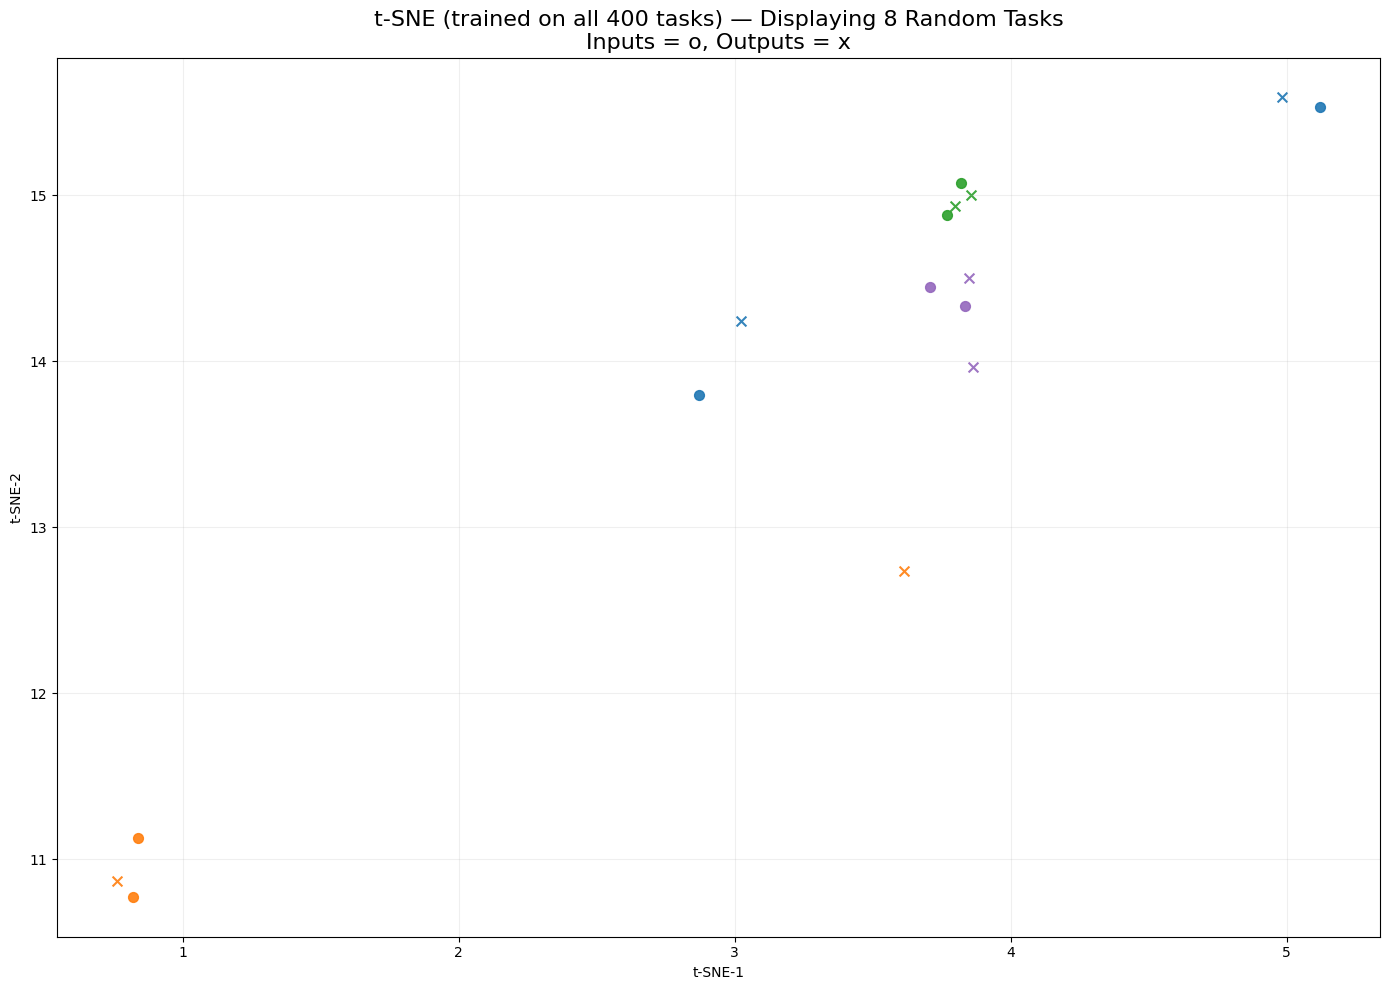

In [24]:
# ----------------------------------------------------
# Pick 8 random tasks for visualization
# ----------------------------------------------------
random.seed(41)
chosen_tasks = random.sample(range(N), 4)

print("Visualizing tasks:", chosen_tasks)

# colormap for 8 colors
cmap = cm.get_cmap('tab10', 8)
task_to_color_idx = {task: i for i, task in enumerate(chosen_tasks)}

# ----------------------------------------------------
# Plot only selected tasks (but using global TSNE coords)
# ----------------------------------------------------
plt.figure(figsize=(14, 10))

point_idx = 0
for task_id, marker in zip(task_ids, markers):
    if task_id not in chosen_tasks:
        point_idx += 1
        continue

    color = cmap(task_to_color_idx[task_id])
    x, y = emb_2d[point_idx]

    plt.scatter(x, y, color=color, marker=marker, s=50, alpha=0.9)

    point_idx += 1

plt.title("t-SNE (trained on all 400 tasks) — Displaying 8 Random Tasks\nInputs = o, Outputs = x", fontsize=16)
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_33130/546663858.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_tasks_to_show)


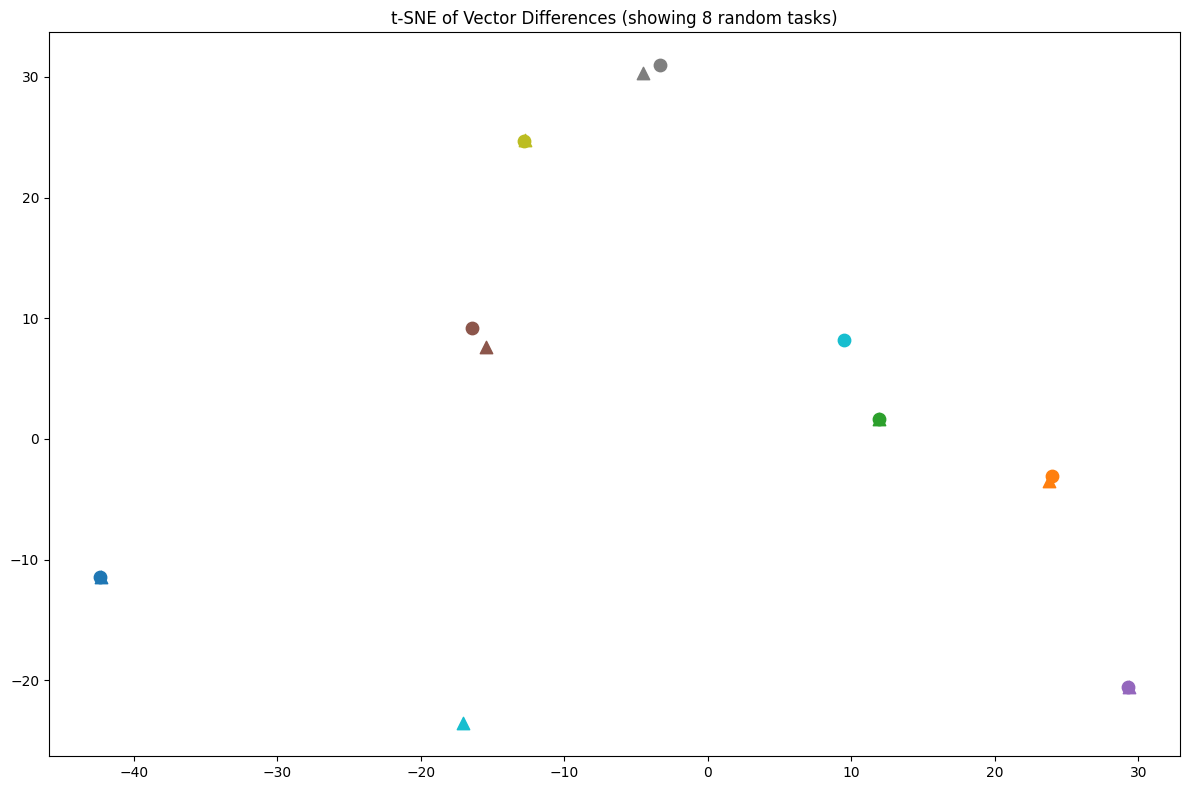

In [25]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import umap


def visualize_difference_tsne(img_in_all, img_out_all, num_tasks_to_show=8):
    # Compute differences: [400, 2, 512]
    diffs = img_out_all - img_in_all
    N, n_examples, D = diffs.shape

    # Flatten: 400×2 → 800
    diffs_flat = diffs.reshape(N * n_examples, D).cpu().numpy()  # [800, 512]

    # Task ids (each repeated twice)
    task_ids = np.repeat(np.arange(N), n_examples)

    # # === t-SNE over ALL 800 difference vectors ===
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init='random',
        random_state=42
    )
    diffs_2d = tsne.fit_transform(diffs_flat)

    # === UMAP over ALL vectors ===
    # reducer = umap.UMAP(
    #     n_components=2,
    #     n_neighbors=30,     # similar to perplexity in t-SNE
    #     min_dist=0.1,       # how tight clusters are
    #     metric="euclidean", # usually best for embeddings
    #     random_state=42
    # )
    # diffs_2d = reducer.fit_transform(diffs_flat)

    # === Select 8 random tasks and extract indices ===
    selected_tasks = random.sample(range(N), num_tasks_to_show)

    selected_indices = []
    for t in selected_tasks:
        idx1 = t * n_examples      # example 1
        idx2 = t * n_examples + 1  # example 2
        selected_indices.extend([idx1, idx2])

    # Colors for 8 tasks
    cmap = cm.get_cmap('tab10', num_tasks_to_show)

    plt.figure(figsize=(12, 8))

    for plot_idx, t in enumerate(selected_tasks):
        # indices for the two diff vectors
        idx1 = t * n_examples
        idx2 = t * n_examples + 1

        color = cmap(plot_idx)

        # first diff vector (circle)
        plt.scatter(
            diffs_2d[idx1, 0], diffs_2d[idx1, 1],
            color=color, marker='o', s=80, label=f"Task {t} (diff 1)" if plot_idx == 0 else None
        )

        # second diff vector (triangle)
        plt.scatter(
            diffs_2d[idx2, 0], diffs_2d[idx2, 1],
            color=color, marker='^', s=80, label=f"Task {t} (diff 2)" if plot_idx == 0 else None
        )

    plt.title("t-SNE of Vector Differences (showing 8 random tasks)")
    plt.tight_layout()
    plt.show()


# Run visualization
visualize_difference_tsne(img_in_all, img_out_all, num_tasks_to_show=8)

/tmp/ipykernel_33130/1378323087.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_tasks_to_show)


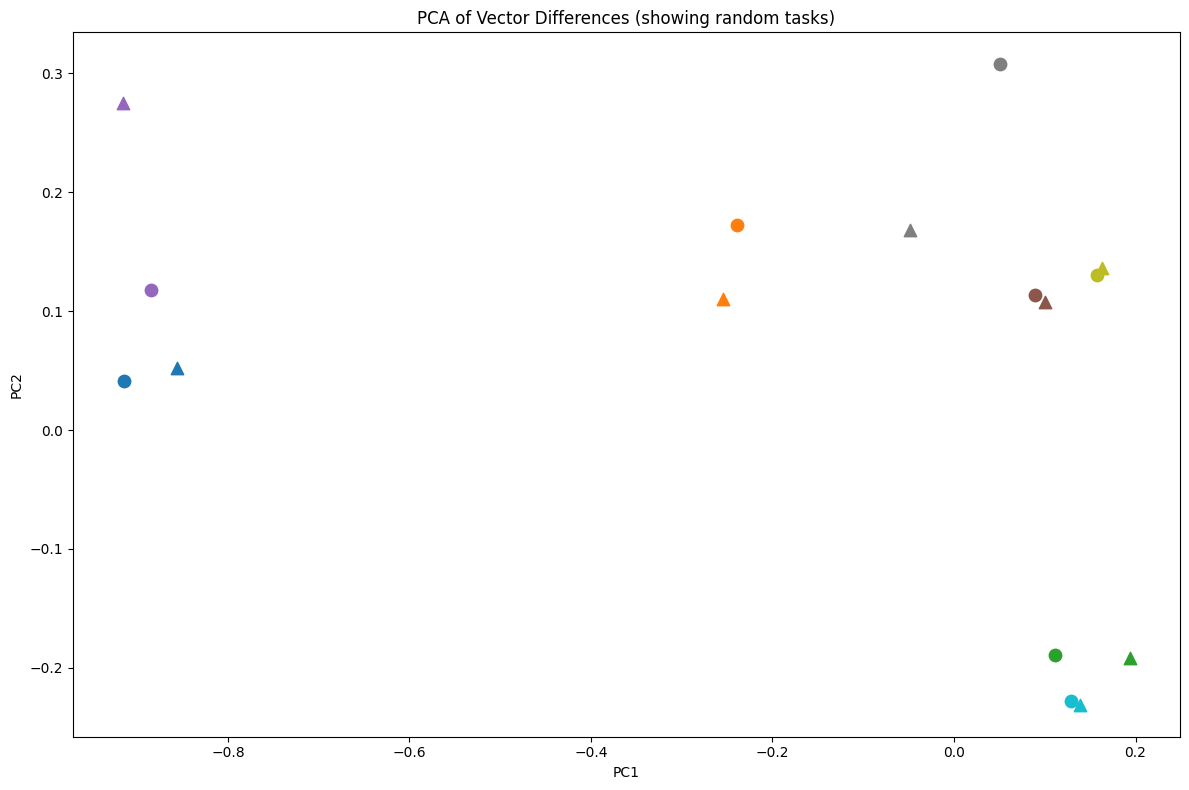

In [27]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random


def visualize_difference_pca(img_in_all, img_out_all, num_tasks_to_show=8):
    # Compute differences: [400, 2, 512]
    diffs = img_out_all - img_in_all
    N, n_examples, D = diffs.shape

    # Flatten: 400×2 → 800
    diffs_flat = diffs.reshape(N * n_examples, D).cpu().numpy()  # [800, 512]

    # Task ids (each repeated twice)
    task_ids = np.repeat(np.arange(N), n_examples)

    # === PCA over ALL difference vectors ===
    pca = PCA(n_components=2, random_state=42)
    diffs_2d = pca.fit_transform(diffs_flat)

    # === Select random tasks ===
    selected_tasks = random.sample(range(N), num_tasks_to_show)

    # Colors for tasks
    cmap = cm.get_cmap('tab10', num_tasks_to_show)

    plt.figure(figsize=(12, 8))

    for plot_idx, t in enumerate(selected_tasks):

        idx1 = t * n_examples
        idx2 = t * n_examples + 1

        color = cmap(plot_idx)

        # diff vector 1
        plt.scatter(
            diffs_2d[idx1, 0],
            diffs_2d[idx1, 1],
            color=color,
            marker='o',
            s=80
        )

        # diff vector 2
        plt.scatter(
            diffs_2d[idx2, 0],
            diffs_2d[idx2, 1],
            color=color,
            marker='^',
            s=80
        )

    plt.title("PCA of Vector Differences (showing random tasks)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


# Run visualization
visualize_difference_pca(img_in_all, img_out_all, num_tasks_to_show=8)

#### PCA all tasks

In [26]:
# ============================================================
# FINAL STYLE-CORRECT + UNCROPPED TASK GRID VISUALIZATION
# with MODE switch: single random task OR full grid
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.patches import FancyArrowPatch
from PIL import Image
from matplotlib.patches import FancyArrowPatch

def fancy_arrow(x, y, dx, dy, color, lw=2.5, alpha=0.9, ms=12):
    arrow = FancyArrowPatch(
        (x, y),
        (x + dx, y + dy),
        arrowstyle='-|>',
        mutation_scale=ms,   # head size in *pixels*
        linewidth=lw,
        color=color,
        alpha=alpha
    )
    plt.gca().add_patch(arrow)

# ============================================================
# Assumed inputs (already exist)
# img_in_all  : torch.Tensor [N, K, D]
# img_out_all : torch.Tensor [N, K, D]
# ============================================================

# ============================
# MODE CONFIGURATION
# ============================
MODE = "all"          # "single" or "all"
SAVE_SINGLE = True    # save image if MODE == "single"
SINGLE_TASK_ID = None # None = random task

# ============================
# Arrow helper
# ============================
def fancy_arrow(
    ax,
    x, y, dx, dy,
    color,
    lw=2.5,
    alpha=0.9,
    ms=12,
    linestyle="-",
):
    arrow = FancyArrowPatch(
        (x, y),
        (x + dx, y + dy),
        arrowstyle='-|>',
        mutation_scale=ms,
        linewidth=lw,
        color=color,
        alpha=alpha,
        linestyle=linestyle,
        clip_on=False,
    )
    ax.add_patch(arrow)

# ============================
# Configuration
# ============================
N, K, D = img_in_all.shape
EXAMPLE_PAIR = (0, 1)

ROWS = 40
COLS = 10
assert ROWS * COLS == N

OUT_DIR = "task_imgs"
OUT_GRID = "all_tasks_grid.png"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================
# Flatten embeddings
# ============================
emb_list = []
for t in range(N):
    for k in range(K):
        emb_list.append(img_in_all[t, k].cpu().numpy())
        emb_list.append(img_out_all[t, k].cpu().numpy())

emb = np.vstack(emb_list)

# ============================
# PCA → 2D (GLOBAL)
# ============================
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(emb)

# ============================
# Recover per-task embeddings
# ============================
emb_2d_inputs, emb_2d_outputs = [], []
idx = 0
for t in range(N):
    for k in range(K):
        emb_2d_inputs.append(emb_2d[idx]); idx += 1
        emb_2d_outputs.append(emb_2d[idx]); idx += 1

emb_2d_inputs  = np.array(emb_2d_inputs).reshape(N, K, 2)
emb_2d_outputs = np.array(emb_2d_outputs).reshape(N, K, 2)

# ============================
# Per-task plot
# ============================
def plot_task(ax, task_id):
    i1, i2 = EXAMPLE_PAIR

    color1 = "tab:blue"
    color2 = "tab:green"

    a1 = emb_2d_inputs[task_id, i1]
    b1 = emb_2d_outputs[task_id, i1]
    a2 = emb_2d_inputs[task_id, i2]
    b2 = emb_2d_outputs[task_id, i2]

    v1 = b1 - a1
    v2 = b2 - a2
    b1_hat = a1 + v2
    err = b1 - b1_hat

    # Points
    ax.scatter(*a1, s=60, color=color1, marker="o", zorder=4)
    ax.scatter(*b1, s=60, color=color1, marker="x", zorder=4)

    ax.scatter(*a2, s=60, color=color2, marker="o", zorder=4)
    ax.scatter(*b2, s=60, color=color2, marker="x", zorder=4)

    ax.scatter(
        *b1_hat,
        s=140,
        marker="*",
        color=color1,
        edgecolor="black",
        linewidth=1.0,
        zorder=6
    )

    # Observed relations
    fancy_arrow(ax, a1[0], a1[1], v1[0], v1[1], color=color1, lw=3.0, ms=14, linestyle="--")
    fancy_arrow(ax, a2[0], a2[1], v2[0], v2[1], color=color2, lw=3.0, ms=14)

    # Inferred relation
    fancy_arrow(ax, a1[0], a1[1], v2[0], v2[1], color=color2, lw=3.0, ms=14, linestyle="--")

    # Error arrow
    fancy_arrow(
        ax,
        b1_hat[0], b1_hat[1],
        err[0], err[1],
        color="black",
        lw=1.5,
        alpha=0.7,
        ms=10
    )

    # Structural dotted lines
    ax.plot(
        [a1[0], a2[0]],
        [a1[1], a2[1]],
        color=color1,
        linewidth=4.0,
        alpha=0.5,
        linestyle=":"
    )

    ax.plot(
        [b1_hat[0], b2[0]],
        [b1_hat[1], b2[1]],
        color=color1,
        linewidth=4.0,
        alpha=0.5,
        linestyle=":"
    )

    # Axis limits (no cropping)
    pts = np.vstack([a1, b1, a2, b2, b1_hat])
    min_xy = pts.min(axis=0)
    max_xy = pts.max(axis=0)
    pad = 0.15 * np.linalg.norm(max_xy - min_xy)

    ax.set_xlim(min_xy[0] - pad, max_xy[0] + pad)
    ax.set_ylim(min_xy[1] - pad, max_xy[1] + pad)

    ax.set_title(f"T{task_id}", fontsize=7)
    ax.axis("off")
    ax.set_aspect("equal")

# ============================
# Single-task helper
# ============================
def plot_single_task(task_id):
    fig, ax = plt.subplots(figsize=(5, 5))
    plot_task(ax, task_id)
    fig.tight_layout(pad=0)

    if SAVE_SINGLE:
        fname = f"{OUT_DIR}/task_{task_id:03d}_single.png"
        fig.savefig(fname, dpi=200)
        print("Saved single task image to:", fname)

    plt.show()

# ============================
# MODE DISPATCH
# ============================
if MODE == "single":
    if SINGLE_TASK_ID is None:
        task_id = random.randint(0, N - 1)
    else:
        task_id = SINGLE_TASK_ID

    print(f"Rendering single task: T{task_id}")
    plot_single_task(task_id)

elif MODE == "all":
    # Render per-task images
    for task_id in range(N):
        fig, ax = plt.subplots(figsize=(2.3, 2.3))
        plot_task(ax, task_id)
        fig.tight_layout(pad=0)
        fig.savefig(f"{OUT_DIR}/task_{task_id:03d}.png", dpi=150)
        plt.close(fig)

    # Concatenate grid
    imgs = [Image.open(f"{OUT_DIR}/task_{i:03d}.png") for i in range(N)]

    w, h = imgs[0].size
    canvas = Image.new("RGB", (COLS * w, ROWS * h), "white")

    for idx, img in enumerate(imgs):
        r = idx // COLS
        c = idx % COLS
        canvas.paste(img, (c * w, r * h))

    canvas.save(OUT_GRID)

    print("Saved per-task images to:", OUT_DIR)
    print("Saved full grid image to:", OUT_GRID)

else:
    raise ValueError("MODE must be 'single' or 'all'")

Saved per-task images to: task_imgs
Saved full grid image to: all_tasks_grid.png
